### Import libraries

In [80]:
import os
import sys
import time
import pathlib
from matplotlib.ticker import ScalarFormatter

### Import Autoencoder class

In [2]:
folder_path = str(pathlib.Path().resolve().parents[1])
print("Folder path =", folder_path)
sys.path.append(folder_path + '/Notebooks/Spatial_AE/')

from model import *
from data import *
from dataloaders import *
from training import *
from plotting import *
from analysis import *

Folder path = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps


### Check GPU

In [4]:
print("CUDA is available =", torch.cuda.is_available())
print("CUDA device count =", torch.cuda.device_count())
if torch.cuda.device_count() > 1:
    os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
print("CUDA device name =", torch.cuda.get_device_name(0))

CUDA is available = True
CUDA device count = 2
CUDA device name = NVIDIA RTX A5000


### Hyperparameters

In [7]:
#Experiment
base_model_training = False
control_model_training = True
RO_model_training = True

save_plots = True

#Model
n_hidden = 200
batch_size = 256
num_epochs = 100
learning_rate = 1e-4
C_factor = 1e3
alpha = 1e5

### Model name

In [9]:
foldername = 'NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)

model_folder_path = folder_path + '/Models/Experiment3/'
plot_folder_path = folder_path + '/Plots/Experiment3/'

check_model_folders(model_folder_path, foldername)
check_plot_folders(plot_folder_path, foldername)

model_folder_path = model_folder_path + foldername
plot_folder_path = plot_folder_path + foldername

loss_csv_filename = model_folder_path + '/loss_history.csv'

print("Model path =", model_folder_path)
print("Plot path  =", plot_folder_path)
print("Loss path  =", loss_csv_filename)

Model path = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Models/Experiment3/NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001
Plot path  = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Plots/Experiment3/NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001
Loss path  = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Models/Experiment3/NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001/loss_history.csv


# Training Double T maze (No Reward Yet)

### Dataset variables

In [16]:
envs = ['DoubleTmazeNoReward', 'DoubleTmazeWithReward']
env = envs[0] #Choose environment index
data_path, csv_filename, num_images = format_dataset(folder_path, env)

print("Dataset Environment =", env)
print("Num. Images in Dataset =", num_images)
print("Dataset Path =", data_path)
print("CSV path =    ", csv_filename)

Dataset Environment = DoubleTmazeNoReward
Num. Images in Dataset = 40001
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/DoubleTmazeNoReward
CSV path =     C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/DoubleTmazeNoReward/data.csv


### Import image dataset and CSV data

In [19]:
DoubleTmaze_dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
DoubleTmaze_data, DoubleTmaze_position, DoubleTmaze_orientation = load_csv(csv_filename, num_images)

frames_to_remove = check_missing_frame(DoubleTmaze_data)
DoubleTmaze_dataset = clean_dataset(DoubleTmaze_dataset, frames_to_remove)

print("Dataset Environment =", env)
print("Dataset Shape =", DoubleTmaze_dataset.shape)
print("Position Shape =", DoubleTmaze_position.shape)
print()
DoubleTmaze_data

Frames ID to be removed from dataset = [19681]
Dataset Environment = DoubleTmazeNoReward
Dataset Shape = (39999, 120, 160, 3)
Position Shape = (39999, 2)



,Trial_number,Trial_time,Frame_ID,Embedding,action,retrieved_action,X,Y,Z,Internal_states,RewardID,Reward_value,n_replays
0,0,1.024,1,[],"[0, 0]",False,-0.000008,-0.009500,270.045416,"[0.499, 0.999, 0.999, 0.999]",0,"[0, 0, 0, 0]",0
1,0,2.048,2,[],"[4.71, 6.28]",False,0.020396,0.090619,298.177441,"[0.498, 0.998, 0.998, 0.998]",0,"[0, 0, 0, 0]",0
2,0,3.072,3,[],"[0.0, 1.57]",False,0.029349,0.108280,330.537874,"[0.497, 0.997, 0.997, 0.997]",0,"[0, 0, 0, 0]",0
3,0,4.096,4,[],"[4.71, 3.14]",False,0.086920,0.156429,300.829370,"[0.496, 0.996, 0.996, 0.996]",0,"[0, 0, 0, 0]",0
4,0,5.120,5,[],"[-0.79, 0.79]",False,0.084543,0.162494,332.615980,"[0.495, 0.995, 0.995, 0.995]",0,"[0, 0, 0, 0]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39994,32,761.856,39996,[],"[4.71, 6.28]",False,-0.801587,-1.003430,285.588582,"[0.0001, 0.256, 0.256, 0.256]",0,"[0, 0, 0, 0]",0
39995,32,762.880,39997,[],"[4.71, 3.93]",False,-0.785099,-0.913312,270.114361,"[0.0001, 0.255, 0.255, 0.255]",0,"[0, 0, 0, 0]",0
39996,32,763.904,39998,[],"[4.71, 3.14]",False,-0.799692,-0.840132,239.542245,"[0.0001, 0.254, 0.254, 0.254]",0,"[0, 0, 0, 0]",0
39997,32,764.928,39999,[],"[3.14, 1.57]",False,-0.831059,-0.816271,207.274266,"[0.0001, 0.253, 0.253, 0.253]",0,"[0, 0, 0, 0]",0


### Display example image

Image shape = (120, 160, 3)


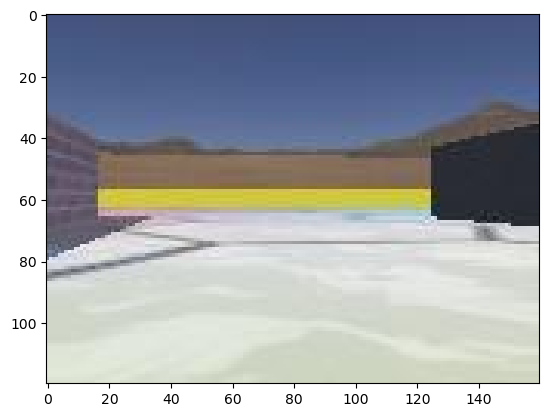

In [21]:
idx = 181
plt.imshow(DoubleTmaze_dataset[idx])
print("Image shape =", DoubleTmaze_dataset[idx].shape)

## Training autoencoder

In [23]:
if base_model_training == True:
    start_time = time.time()
    model = Conv_AE(n_hidden=n_hidden)
    train_loader = create_dataloader(DoubleTmaze_dataset, batch_size=batch_size)
    history, _= train_autoencoder(model, train_loader, num_epochs=num_epochs, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)

    elapsed_time = time.time() - start_time
    hours, remainder = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(remainder, 60)
    timer = "Training duration: " + "{:02}:{:02}:{:02}".format(int(hours), int(minutes), int(seconds))
    print(timer, end="\r")

    #Saving loss history in a CSV file
    save_training_loss(loss_csv_filename, history)

    model_filename =  foldername + '.pth'
    model_path = model_folder_path + '/' + model_filename
    print("Autoencoder saved at", model_path)
    torch.save(model.state_dict(), model_path)

In [29]:
if base_model_training == False:
    foldername = 'NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)
    model_filename =  foldername + '.pth'
    model_path = model_folder_path + '/' + model_filename

    try:
        model = Conv_AE(n_hidden=n_hidden)
        model.load_state_dict(torch.load(model_path))
        print("Model loaded:", model_path)
    except:
      print("An exception occurred - No available Autoencoder at", model_path)

Model loaded: C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Models/Experiment3/NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001/NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001.pth


In [31]:
if base_model_training == True:
    fig = plt.figure(figsize=(6,4))
    plt.plot(history)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    sb.despine()
    plt.suptitle(env + ' history loss', fontsize=15)
    plt.title('Final loss = ' + str(round(history[-1], 5)), fontsize=10)
    plt.show()

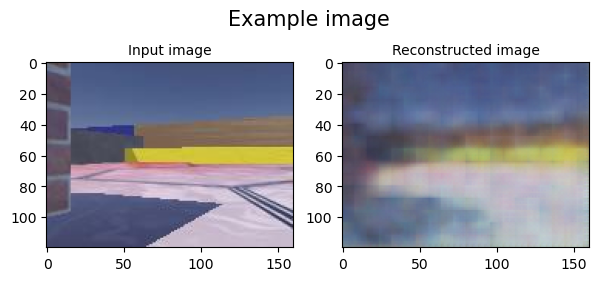

In [33]:
img_indx = 10

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(DoubleTmaze_dataset[img_indx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(DoubleTmaze_dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()

In [34]:
DoubleTmaze_embeddings = get_latent_vectors(DoubleTmaze_dataset, model, batch_size=batch_size)

In [36]:
DoubleTmaze_all_ratemaps = ratemaps(DoubleTmaze_embeddings, DoubleTmaze_position, n_bins=50, filter_width=3)

In [37]:
plot_ratemaps(DoubleTmaze_all_ratemaps[0:100], plot_folder_path, save=save_plots)

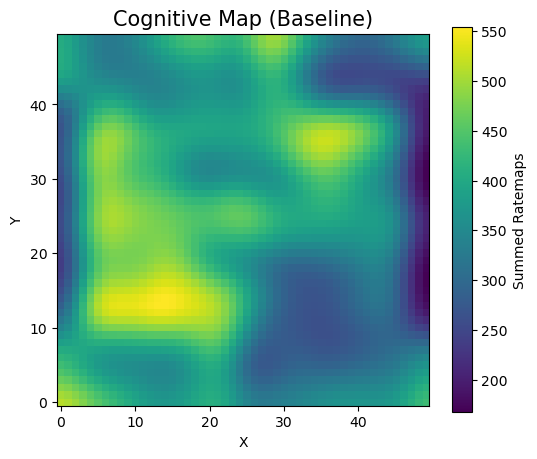

In [38]:
DoubleTmaze_ratemap_sum = np.sum(DoubleTmaze_all_ratemaps, axis=0)

# Plot
fig = plt.figure(figsize=(6,5))
plt.imshow(DoubleTmaze_ratemap_sum, origin='lower', cmap='viridis')
plt.colorbar(label='Summed Ratemaps')
plt.title('Cognitive Map (Baseline)', fontsize=15)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
if save_plots:
    fig.savefig(plot_folder_path + '/CogMap-Baseline.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/CogMap-Baseline.png', format='png')

# Training Control NoRO Double T maze

In [100]:
env = envs[1] #Load Doble T maze environment with Reward object
data_path, csv_filename, num_images = format_dataset(folder_path, env)

print("Dataset Environment =", env)
print("Num. Images in Dataset =", num_images)
print("Dataset Path =", data_path)
print("CSV path =    ", csv_filename)

Dataset Environment = DoubleTmazeWithReward
Num. Images in Dataset = 40000
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/DoubleTmazeWithReward
CSV path =     C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/DoubleTmazeWithReward/data.csv


In [102]:
DoubleTmaze_dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
DoubleTmaze_data, DoubleTmaze_position, DoubleTmaze_orientation = load_csv(csv_filename, num_images)

frames_to_remove = check_missing_frame(DoubleTmaze_data)
DoubleTmaze_dataset = clean_dataset(DoubleTmaze_dataset, frames_to_remove)

print("Dataset Environment =", env)
print("Dataset Shape =", DoubleTmaze_dataset.shape)
print("Position Shape =", DoubleTmaze_position.shape)
print()
DoubleTmaze_data

Frames ID to be removed from dataset = [38913]
Dataset Environment = DoubleTmazeWithReward
Dataset Shape = (39999, 120, 160, 3)
Position Shape = (39999, 2)



,Trial_number,Trial_time,Frame_ID,Embedding,action,retrieved_action,X,Y,Z,Internal_states,RewardID,Reward_value,n_replays
0,0,1.024,1,[],"[0, 0]",False,-0.000008,-0.009500,270.045416,"[0.999, 0.999, 0.499, 0.999]",0,"[0, 0, 0, 0]",0
1,0,2.048,2,[],"[3.14, 4.71]",False,0.014773,0.063646,300.698986,"[0.998, 0.998, 0.498, 0.998]",0,"[0, 0, 0, 0]",0
2,0,3.072,3,[],"[-0.79, 0.79]",False,0.012561,0.069629,333.209381,"[0.997, 0.997, 0.497, 0.997]",0,"[0, 0, 0, 0]",0
3,0,4.096,4,[],"[1.57, 3.14]",False,0.055525,0.082921,4.717325,"[0.996, 0.996, 0.496, 0.996]",0,"[0, 0, 0, 0]",0
4,0,5.120,5,[],"[1.57, 0.0]",False,0.073134,0.080475,334.251614,"[0.995, 0.995, 0.495, 0.995]",0,"[0, 0, 0, 0]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39994,27,811.008,39996,[],"[6.28, 6.28]",False,0.704303,0.916157,309.410819,"[0.0001, 0.208, 0.208, 0.208]",0,"[0, 0, 0, 0]",0
39995,27,812.032,39997,[],"[0.79, -0.79]",False,0.711441,0.917172,278.890626,"[0.0001, 0.207, 0.207, 0.207]",0,"[0, 0, 0, 0]",0
39996,27,813.056,39998,[],"[1.57, 0.0]",False,0.714613,0.933195,246.501770,"[0.0001, 0.206, 0.206, 0.206]",0,"[0, 0, 0, 0]",0
39997,27,814.080,39999,[],"[0.0, 1.57]",False,0.707339,0.947098,274.827475,"[0.0001, 0.205, 0.205, 0.205]",0,"[0, 0, 0, 0]",0


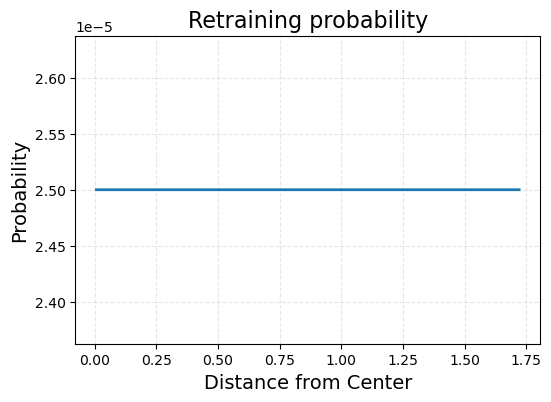

In [103]:
center = np.array([0.0, 0.0])
overrepresentation_bias = 0.0

distances = calculate_distances(DoubleTmaze_position, center)
probabilities = compute_probabilities(distances, decay_factor=overrepresentation_bias)

idx = distances.argsort()

fig = plt.figure(figsize=(6, 4))
plt.plot(distances[idx], probabilities[idx], linewidth=2)
plt.xlabel("Distance from Center", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.title("Retraining probability", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

In [104]:
train_loader, extra_indices = create_mixed_biased_dataloader(
    DoubleTmaze_dataset, probabilities, bias_ratio=2, batch_size=batch_size
)

extra_rows = DoubleTmaze_data.iloc[extra_indices].copy()
DoubleTmaze_data = pd.concat([DoubleTmaze_data, extra_rows], ignore_index=True)
len(train_loader.dataset)

119997

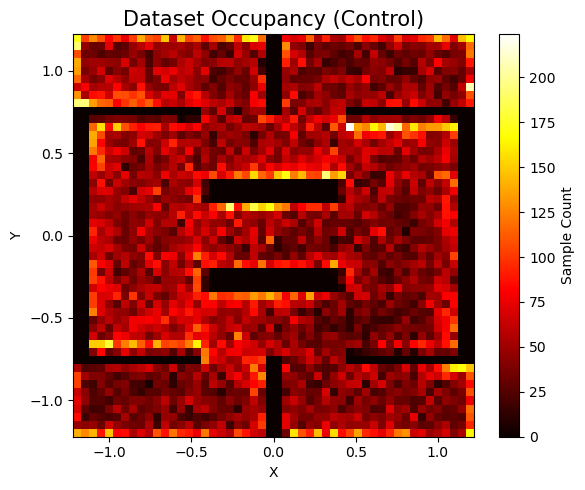

In [105]:
fig = plt.figure(figsize=(6, 5))
plt.hist2d(DoubleTmaze_data['X'], DoubleTmaze_data['Y'], bins=50, cmap='hot')
plt.colorbar(label='Sample Count')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset Occupancy (Control)', fontsize=15)
plt.tight_layout()
plt.show()
if save_plots:
    fig.savefig(plot_folder_path + '/Dataset-Control.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Dataset-Control.png', format='png')

Image shape = (120, 160, 3)


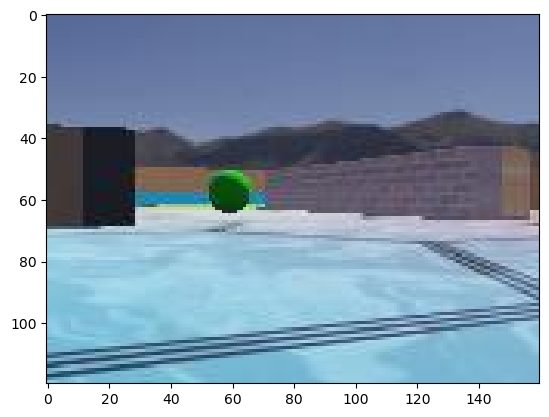

In [106]:
idx = 40
plt.imshow(DoubleTmaze_dataset[idx])
print("Image shape =", DoubleTmaze_dataset[idx].shape)

In [56]:
loss_csv_filename = model_folder_path + '/NoRO_loss_history.csv'
history = []

if control_model_training == True:
    start_time = time.time()
    history, _= train_autoencoder(model, train_loader, num_epochs=num_epochs, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)

    elapsed_time = time.time() - start_time
    hours, remainder = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(remainder, 60)
    timer = "Training duration: " + "{:02}:{:02}:{:02}".format(int(hours), int(minutes), int(seconds))
    print(timer, end="\r")

    #Saving loss history in a CSV file
    save_training_loss(loss_csv_filename, history)

    model_filename =  'NoRO' + foldername + '.pth'
    model_path = model_folder_path + '/' + model_filename
    print("Autoencoder saved at", model_path)
    torch.save(model.state_dict(), model_path)
    
else:
    foldername = 'Experiment3-NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)
    model_filename =  'NoRO' + foldername + '.pth'
    model_path = model_folder_path + '/' + model_filename

    try:
        model = Conv_AE(n_hidden=n_hidden)
        model.load_state_dict(torch.load(model_path))
        print("Model loaded:", model_path)
    except:
      print("An exception occurred - No available Autoencoder at", model_path)

Epoch 100/100, Loss: 0.0102: 100%|███████████████████████████████████████████████████| 469/469 [00:41<00:00, 11.19it/s]


Loss History saved at C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Models/Experiment3/NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001/NoRO_loss_history.csv
Autoencoder saved at C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Models/Experiment3/NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001/NoRONEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001.pth


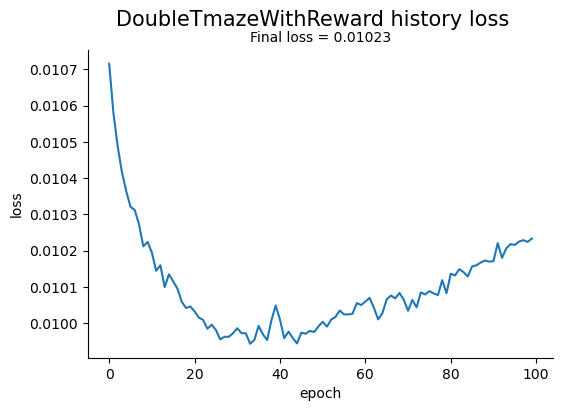

In [58]:
if control_model_training == True:
    fig = plt.figure(figsize=(6,4))
    plt.plot(history)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    sb.despine()
    plt.suptitle(env + ' history loss', fontsize=15)
    plt.title('Final loss = ' + str(round(history[-1], 5)), fontsize=10)
    plt.show()

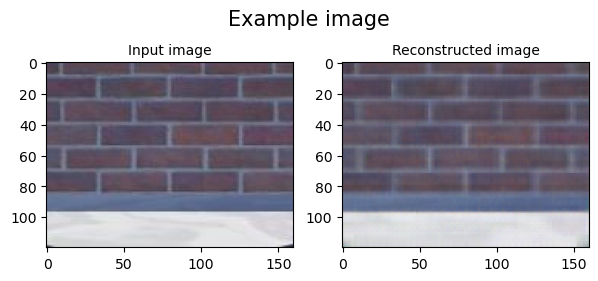

In [107]:
img_indx = 0

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(DoubleTmaze_dataset[img_indx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(DoubleTmaze_dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()

In [62]:
DoubleTmaze_NoRO_embeddings = get_latent_vectors(DoubleTmaze_dataset, model, batch_size=batch_size)

In [63]:
DoubleTmaze_NoRO_all_ratemaps = ratemaps(DoubleTmaze_NoRO_embeddings, DoubleTmaze_position, n_bins=50, filter_width=3)

In [64]:
plot_ratemaps(DoubleTmaze_NoRO_all_ratemaps[0:100], plot_folder_path, save=save_plots)

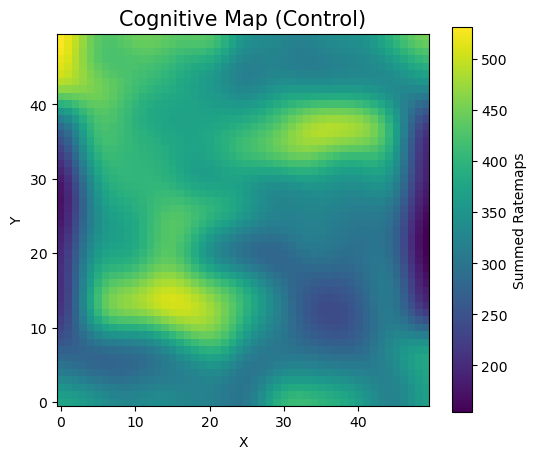

In [65]:
DoubleTmaze_NoRO_ratemap_sum = np.sum(DoubleTmaze_NoRO_all_ratemaps, axis=0)

# Plot
fig = plt.figure(figsize=(6,5))
plt.imshow(DoubleTmaze_NoRO_ratemap_sum, origin='lower', cmap='viridis')
plt.colorbar(label='Summed Ratemaps')
plt.title('Cognitive Map (Control)', fontsize=15)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
if save_plots:
    fig.savefig(plot_folder_path + '/CogMap-Control.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/CogMap-Control.png', format='png')

# Training Reward Overrepresented Double T maze

## Biasing dataset

In [70]:
env = envs[1] #Load Double T maze with reward
data_path, csv_filename, num_images = format_dataset(folder_path, env)

print("Dataset Environment =", env)
print("Num. Images in Dataset =", num_images)
print("Dataset Path =", data_path)
print("CSV path =    ", csv_filename)

Dataset Environment = DoubleTmazeWithReward
Num. Images in Dataset = 40000
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/DoubleTmazeWithReward
CSV path =     C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/DoubleTmazeWithReward/data.csv


In [72]:
DoubleTmaze_dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
DoubleTmaze_data, DoubleTmaze_position, DoubleTmaze_orientation = load_csv(csv_filename, num_images)

frames_to_remove = check_missing_frame(DoubleTmaze_data)
DoubleTmaze_dataset = clean_dataset(DoubleTmaze_dataset, frames_to_remove)

print("Dataset Environment =", env)
print("Dataset Shape =", DoubleTmaze_dataset.shape)
print("Position Shape =", DoubleTmaze_position.shape)
print()
DoubleTmaze_data

Frames ID to be removed from dataset = [38913]
Dataset Environment = DoubleTmazeWithReward
Dataset Shape = (39999, 120, 160, 3)
Position Shape = (39999, 2)



,Trial_number,Trial_time,Frame_ID,Embedding,action,retrieved_action,X,Y,Z,Internal_states,RewardID,Reward_value,n_replays
0,0,1.024,1,[],"[0, 0]",False,-0.000008,-0.009500,270.045416,"[0.999, 0.999, 0.499, 0.999]",0,"[0, 0, 0, 0]",0
1,0,2.048,2,[],"[3.14, 4.71]",False,0.014773,0.063646,300.698986,"[0.998, 0.998, 0.498, 0.998]",0,"[0, 0, 0, 0]",0
2,0,3.072,3,[],"[-0.79, 0.79]",False,0.012561,0.069629,333.209381,"[0.997, 0.997, 0.497, 0.997]",0,"[0, 0, 0, 0]",0
3,0,4.096,4,[],"[1.57, 3.14]",False,0.055525,0.082921,4.717325,"[0.996, 0.996, 0.496, 0.996]",0,"[0, 0, 0, 0]",0
4,0,5.120,5,[],"[1.57, 0.0]",False,0.073134,0.080475,334.251614,"[0.995, 0.995, 0.495, 0.995]",0,"[0, 0, 0, 0]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39994,27,811.008,39996,[],"[6.28, 6.28]",False,0.704303,0.916157,309.410819,"[0.0001, 0.208, 0.208, 0.208]",0,"[0, 0, 0, 0]",0
39995,27,812.032,39997,[],"[0.79, -0.79]",False,0.711441,0.917172,278.890626,"[0.0001, 0.207, 0.207, 0.207]",0,"[0, 0, 0, 0]",0
39996,27,813.056,39998,[],"[1.57, 0.0]",False,0.714613,0.933195,246.501770,"[0.0001, 0.206, 0.206, 0.206]",0,"[0, 0, 0, 0]",0
39997,27,814.080,39999,[],"[0.0, 1.57]",False,0.707339,0.947098,274.827475,"[0.0001, 0.205, 0.205, 0.205]",0,"[0, 0, 0, 0]",0


### Expand dataset with bias toward reward

In [74]:
center = np.array([0.0, 0.0])
overrepresentation_bias = 4.0

distances = calculate_distances(DoubleTmaze_position, center)
RO_probabilities = compute_probabilities(distances, decay_factor=overrepresentation_bias)
biased_loader, extra_indices = create_mixed_biased_dataloader(
    DoubleTmaze_dataset, RO_probabilities, bias_ratio=2, batch_size=batch_size
)

extra_rows = DoubleTmaze_data.iloc[extra_indices].copy()
DoubleTmaze_data_biased = pd.concat([DoubleTmaze_data, extra_rows], ignore_index=True)

In [75]:
len(biased_loader.dataset)

119997

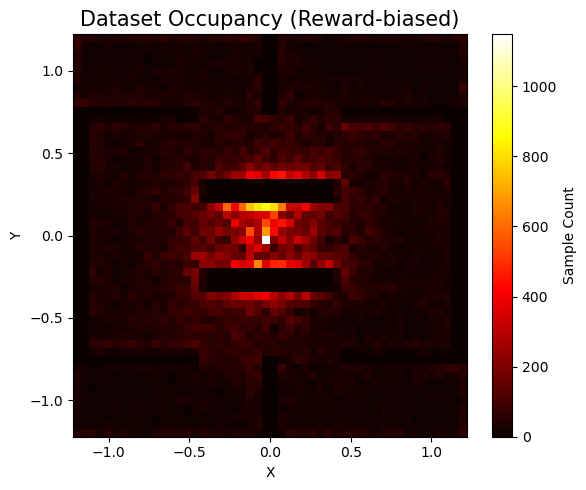

In [76]:
fig = plt.figure(figsize=(6, 5))
plt.hist2d(DoubleTmaze_data_biased['X'], DoubleTmaze_data_biased['Y'], bins=50, cmap='hot')
plt.colorbar(label='Sample Count')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset Occupancy (Reward-biased)', fontsize=15)
plt.tight_layout()
plt.show()
if save_plots:
    fig.savefig(plot_folder_path + '/Dataset-RO.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Dataset-RO.png', format='png')

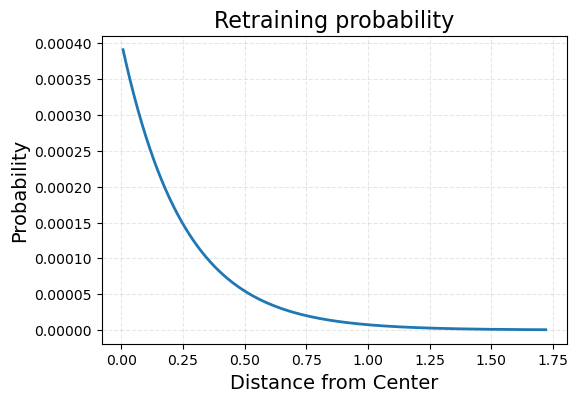

In [77]:
idx = distances.argsort()

fig = plt.figure(figsize=(6, 4))
plt.plot(distances[idx], RO_probabilities[idx], linewidth=2)
plt.xlabel("Distance from Center", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.title("Retraining probability", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

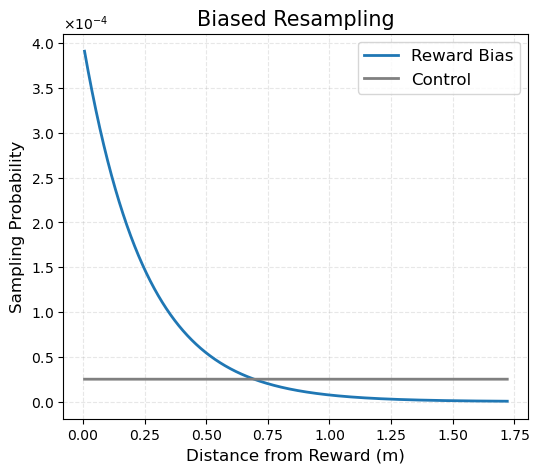

In [82]:
idx = distances.argsort()
fig = plt.figure(figsize=(6, 5))
plt.plot(distances[idx], RO_probabilities[idx], linewidth=2, label='Reward Bias')
plt.plot(distances[idx], probabilities[idx], linewidth=2, color='gray', label='Control')
plt.xlabel("Distance from Reward (m)", fontsize=12)
plt.ylabel("Sampling Probability", fontsize=12)
plt.title("Biased Resampling", fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.show()

if save_plots:
    fig.savefig(plot_folder_path + '/Resampling.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Resampling.png', format='png')

In [84]:
foldername = 'NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)
model_filename =  foldername + '.pth'
model_path = model_folder_path + '/' + model_filename

try:
    model = Conv_AE(n_hidden=n_hidden)
    model.load_state_dict(torch.load(model_path))
    print("Model loaded:", model_path)
except:
  print("An exception occurred - No available Autoencoder at", model_path)

Model loaded: C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Models/Experiment3/NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001/NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001.pth


In [86]:
loss_csv_filename = model_folder_path + '/RO_loss_history.csv'
history = []

if RO_model_training == True:
    start_time = time.time()
    history, _= train_autoencoder(model, biased_loader, num_epochs=num_epochs, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)

    elapsed_time = time.time() - start_time
    hours, remainder = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(remainder, 60)
    timer = "Training duration: " + "{:02}:{:02}:{:02}".format(int(hours), int(minutes), int(seconds))
    print(timer, end="\r")

    #Saving loss history in a CSV file
    save_training_loss(loss_csv_filename, history)

    model_filename =  'RO' + foldername + '.pth'
    model_path = model_folder_path + '/' + model_filename
    print("Autoencoder saved at", model_path)
    torch.save(model.state_dict(), model_path)
    
else:
    foldername = 'Experiment3-NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)
    model_filename =  'RO' + foldername + '.pth'
    model_path = model_folder_path + '/' + model_filename

    try:
        model = Conv_AE(n_hidden=n_hidden)
        model.load_state_dict(torch.load(model_path))
        print("Model loaded:", model_path)
    except:
      print("An exception occurred - No available Autoencoder at", model_path)

Epoch 100/100, Loss: 0.0102: 100%|███████████████████████████████████████████████████| 469/469 [00:38<00:00, 12.11it/s]


Loss History saved at C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Models/Experiment3/NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001/RO_loss_history.csv
Autoencoder saved at C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Models/Experiment3/NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001/RONEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001.pth


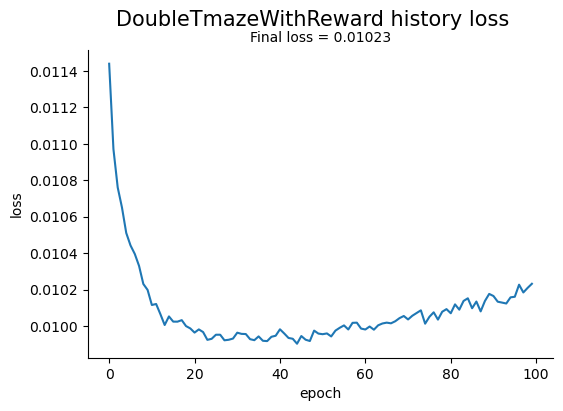

In [88]:
if RO_model_training == True:
    fig = plt.figure(figsize=(6,4))
    plt.plot(history)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    sb.despine()
    plt.suptitle(env + ' history loss', fontsize=15)
    plt.title('Final loss = ' + str(round(history[-1], 5)), fontsize=10)
    plt.show()

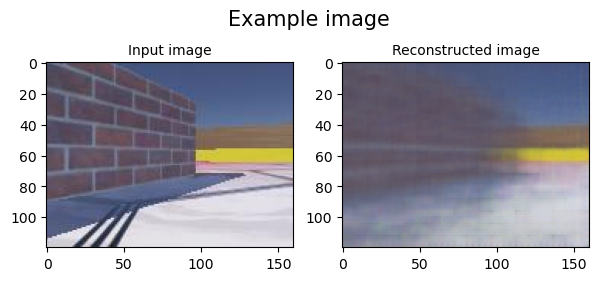

In [90]:
img_indx = 2

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(DoubleTmaze_dataset[img_indx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(DoubleTmaze_dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()

In [92]:
DoubleTmaze_RO_embeddings = get_latent_vectors(DoubleTmaze_dataset, model, batch_size=batch_size)

In [93]:
DoubleTmaze_RO_all_ratemaps = ratemaps(DoubleTmaze_RO_embeddings, DoubleTmaze_position, n_bins=50, filter_width=3)

In [94]:
plot_ratemaps(DoubleTmaze_RO_all_ratemaps[0:100], plot_folder_path, save=save_plots)

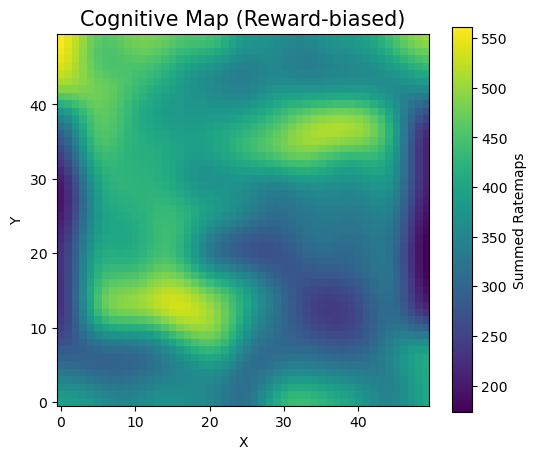

In [95]:
DoubleTmaze_RO_ratemap_sum = np.sum(DoubleTmaze_RO_all_ratemaps, axis=0)

# Plot
fig = plt.figure(figsize=(6,5))
plt.imshow(DoubleTmaze_RO_ratemap_sum, origin='lower', cmap='viridis')
plt.colorbar(label='Summed Ratemaps')
plt.title('Cognitive Map (Reward-biased)', fontsize=15)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
if save_plots:
    fig.savefig(plot_folder_path + '/CogMap-RO.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/CogMap-RO.png', format='png')